In [ ]:
!python -m venv hw2enviro

In [103]:
#importo las librerias requeridas
import requests
import pandas as pd
from datetime import datetime
import json
import os

In [105]:
# Carpeta base para guardar los datos de los concursos
carpeta_base = "concursos_codeforces"
os.makedirs(carpeta_base, exist_ok=True)

In [106]:
print("Obteniendo la lista de concursos...")
contest_list_url = "https://codeforces.com/api/contest.list?"
response_concursos = requests.get(contest_list_url)
response_concursos.raise_for_status()  # Lanza una excepción si la solicitud falla
concursos_data = response_concursos.json()

Obteniendo la lista de concursos...


In [107]:
# Convertimos el timestamp a una fecha legible
def convertir_fecha(timestamp):
 return datetime.fromtimestamp(timestamp)

In [108]:
if concursos_data['status'] == 'OK':
    contests = concursos_data['result']
    print(json.dumps(concursos_data, indent=4))
else:
    print("Error")

{
    "status": "OK",
    "result": [
        {
            "id": 2101,
            "name": "Codeforces Round (Div. 1)",
            "type": "CF",
            "phase": "BEFORE",
            "frozen": false,
            "durationSeconds": 9000,
            "startTimeSeconds": 1746974100,
            "relativeTimeSeconds": -2126443
        },
        {
            "id": 2102,
            "name": "Codeforces Round (Div. 2)",
            "type": "CF",
            "phase": "BEFORE",
            "frozen": false,
            "durationSeconds": 9000,
            "startTimeSeconds": 1746974100,
            "relativeTimeSeconds": -2126443
        },
        {
            "id": 2099,
            "name": "Codeforces Round (Div. 1)",
            "type": "CF",
            "phase": "BEFORE",
            "frozen": false,
            "durationSeconds": 7200,
            "startTimeSeconds": 1746261300,
            "relativeTimeSeconds": -1413643
        },
        {
            "id": 2100,
            "

In [ ]:
#averrrrrrr

In [1]:
import os
import requests
import json
import pandas as pd
from datetime import datetime
import re

# Ruta base donde guardarás las carpetas
ruta_base = r"C:\Users\Nadia Copello\Documents\GitHub\clases de lab\concursos_codeforces"

# Función para limpiar nombres de carpeta
def limpiar_nombre(nombre):
    return re.sub(r'[<>:"/\\|?*]', '_', nombre)

# Función para convertir epoch a datetime
def epoch_a_fecha(epoch):
    return datetime.utcfromtimestamp(epoch)

# Traer la lista de concursos
url = "https://codeforces.com/api/contest.list"
response = requests.get(url)
data = response.json()

if data["status"] != "OK":
    print("❌ Error al obtener la lista de concursos")
else:
    concursos = data["result"]

    for concurso in concursos:
        nombre = concurso["name"]
        fecha = epoch_a_fecha(concurso["startTimeSeconds"])

        if ("Hello" in nombre or "Round" in nombre or "Good Bye" in nombre) and (datetime(2024, 7, 1) <= fecha <= datetime(2024, 12, 31)):
            contest_id = concurso["id"]
            nombre_limpio = limpiar_nombre(nombre)[:100]
            carpeta_concurso = os.path.join(ruta_base, f"{contest_id}_{nombre_limpio}")
            os.makedirs(carpeta_concurso, exist_ok=True)

            print(f"\n📥 Descargando datos de: {nombre}")

            # Obtener standings y problemas
            try:
                standings_url = f"https://codeforces.com/api/contest.standings?contestId={contest_id}&from=1&count=50"
                standings = requests.get(standings_url).json()
                if standings['status'] == 'OK':
                    pd.DataFrame(standings['result']['rows']).to_csv(os.path.join(carpeta_concurso, "standings.csv"), index=False)
                    pd.DataFrame(standings['result']['problems']).to_csv(os.path.join(carpeta_concurso, "problems.csv"), index=False)
                    print("   - Standings y problemas guardados")
                else:
                    print(f"   - No se pudieron obtener standings: {standings.get('comment', '')}")
            except Exception as e:
                print(f"   - Error en standings: {e}")

            # Obtener lista de usuarios rateados
            try:
                rated_list_url = f"https://codeforces.com/api/contest.ratingChanges?contestId={contest_id}"
                rated_list_response = requests.get(rated_list_url)
                rated_list_response.raise_for_status()
                rated_list_data = rated_list_response.json()

                if rated_list_data['status'] == 'OK' and 'result' in rated_list_data:
                    handles = [user['handle'] for user in rated_list_data['result']]
                    df = pd.DataFrame(handles, columns=['handle'])
                    df.to_csv(os.path.join(carpeta_concurso, 'handles_rateados.csv'), index=False)
                    print("   - Handles guardados en handles_rateados.csv")
                elif rated_list_data['status'] != 'OK':
                    print(f"   - No se pudo obtener la lista de usuarios rateados: {rated_list_data.get('comment', '')}")
                else:
                    print("   - No se encontraron usuarios rateados para este concurso.")
            except Exception as e:
                print(f"   - Error al obtener handles rateados: {e}")

            # Obtener los envíos
            try:
                status_url = f"https://codeforces.com/api/contest.status?contestId={contest_id}&from=1&count=5000"
                status_response = requests.get(status_url)
                status_response.raise_for_status()
                status_data = status_response.json()

                if status_data['status'] == 'OK' and 'result' in status_data:
                    submissions = status_data['result']
                    print(f"   - Envíos del concurso {contest_id}:")
                    lista_envios = []

                    for submission in submissions:
                        submission_id = submission.get('id')
                        user_handle = submission.get('author', {}).get('members', [{}])[0].get('handle')
                        problem_name = submission.get('problem', {}).get('name')
                        verdict = submission.get('verdict')
                        language = submission.get('programmingLanguage')
                        creation_time = submission.get('creationTimeSeconds')

                        lista_envios.append({
                            'submission_id': submission_id,
                            'user_handle': user_handle,
                            'problem_name': problem_name,
                            'verdict': verdict,
                            'language': language,
                            'creation_time': creation_time
                        })

                    df_envios = pd.DataFrame(lista_envios)
                    df_envios.to_csv(os.path.join(carpeta_concurso, 'submissions.csv'), index=False)
                    print("   - Envíos guardados en submissions.csv")

                elif status_data['status'] != 'OK':
                    print(f"   - No se pudieron obtener los envíos: {status_data.get('comment', '')}")
                else:
                    print("   - No se encontraron envíos para este concurso.")
            except Exception as e:
                print(f"   - Error al obtener los envíos: {e}")

            # Cambios en calificación
            try:
                rated_changes_url = f'https://codeforces.com/api/contest.ratingChanges?contestId={contest_id}'
                rated_changes_response = requests.get(rated_changes_url)
                rated_changes_response.raise_for_status()
                rated_changes_data = rated_changes_response.json()

                if rated_changes_data['status'] == 'OK' and 'result' in rated_changes_data:
                    rating_changes = rated_changes_data['result']
                    print(f'   - Cambios en la calificación del concurso {contest_id}:')
                    lista_cambios = []

                    for change in rating_changes:
                        handle = change.get('handle')
                        old_rating = change.get('oldRating')
                        new_rating = change.get('newRating')
                        rating_change = new_rating - old_rating

                        lista_cambios.append({
                            'handle': handle,
                            'old_rating': old_rating,
                            'new_rating': new_rating,
                            'change': rating_change,
                            'rank': change.get('rank'),
                            'contest_id': change.get('contestId'),
                            'contest_name': change.get('contestName')
                        })

                    df_cambios = pd.DataFrame(lista_cambios)
                    df_cambios.to_csv(os.path.join(carpeta_concurso, 'rating_changes.csv'), index=False)
                    print("   - Cambios de calificación guardados en rating_changes.csv")

                elif rated_changes_data['status'] != 'OK':
                    print(f"   - No se pudieron obtener los cambios: {rated_changes_data.get('comment', '')}")
                else:
                    print("   - No se encontraron cambios de calificación.")
            except Exception as e:
                print(f"   - Error al obtener cambios de calificación: {e}")


C:\Users\Nadia Copello\AppData\Local\Temp\ipykernel_11052\4074276651.py:17: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.utcfromtimestamp(epoch)



📥 Descargando datos de: Good Bye 2024: 2025 is NEAR
   - Standings y problemas guardados
   - Handles guardados en handles_rateados.csv
   - Envíos del concurso 2053:
   - Envíos guardados en submissions.csv
   - Cambios en la calificación del concurso 2053:
   - Cambios de calificación guardados en rating_changes.csv

📥 Descargando datos de: Educational Codeforces Round 173 (Rated for Div. 2)
   - Standings y problemas guardados
   - Handles guardados en handles_rateados.csv
   - Envíos del concurso 2043:
   - Envíos guardados en submissions.csv
   - Cambios en la calificación del concurso 2043:
   - Cambios de calificación guardados en rating_changes.csv

📥 Descargando datos de: Codeforces Round 995 (Div. 3)
   - Standings y problemas guardados
   - Handles guardados en handles_rateados.csv
   - Envíos del concurso 2051:
   - Envíos guardados en submissions.csv
   - Cambios en la calificación del concurso 2051:
   - Cambios de calificación guardados en rating_changes.csv

📥 Descarga

C:\Users\Nadia Copello\AppData\Local\Temp\ipykernel_11052\4074276651.py:17: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.utcfromtimestamp(epoch)


   - Standings y problemas guardados
   - Handles guardados en handles_rateados.csv
   - Envíos del concurso 2008:
   - Envíos guardados en submissions.csv
   - Cambios en la calificación del concurso 2008:
   - Cambios de calificación guardados en rating_changes.csv

📥 Descargando datos de: Codeforces Round 969 (Div. 1)
   - Standings y problemas guardados
   - Handles guardados en handles_rateados.csv
   - Envíos del concurso 2006:
   - Envíos guardados en submissions.csv
   - Cambios en la calificación del concurso 2006:
   - Cambios de calificación guardados en rating_changes.csv

📥 Descargando datos de: Codeforces Round 969 (Div. 2)
   - Standings y problemas guardados
   - Handles guardados en handles_rateados.csv
   - Envíos del concurso 2007:
   - Envíos guardados en submissions.csv
   - Cambios en la calificación del concurso 2007:
   - Cambios de calificación guardados en rating_changes.csv

📥 Descargando datos de: Testing Round 19 (Div. 3)
   - Standings y problemas guardado

C:\Users\Nadia Copello\AppData\Local\Temp\ipykernel_11052\4074276651.py:17: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.utcfromtimestamp(epoch)


   - Standings y problemas guardados
   - Handles guardados en handles_rateados.csv
   - Envíos del concurso 2003:
   - Envíos guardados en submissions.csv
   - Cambios en la calificación del concurso 2003:
   - Cambios de calificación guardados en rating_changes.csv

📥 Descargando datos de: Codeforces Round 967 (Div. 2)
   - Standings y problemas guardados
   - Handles guardados en handles_rateados.csv
   - Envíos del concurso 2001:
   - Envíos guardados en submissions.csv
   - Cambios en la calificación del concurso 2001:
   - Cambios de calificación guardados en rating_changes.csv

📥 Descargando datos de: Educational Codeforces Round 169 (Rated for Div. 2)
   - Standings y problemas guardados
   - Handles guardados en handles_rateados.csv
   - Envíos del concurso 2004:
   - Envíos guardados en submissions.csv
   - Cambios en la calificación del concurso 2004:
   - Cambios de calificación guardados en rating_changes.csv

📥 Descargando datos de: Codeforces Round 966 (Div. 3)
   - Stan

## Descripción del proyecto:

## Puntos finales de la API utilizados

Durante la recolección de datos se utilizaron los siguientes endpoints públicos de la API de Codeforces:

1. `https://codeforces.com/api/contest.list`: lista de todos los concursos realizados (con nombre, fecha, id, etc.).
2. `https://codeforces.com/api/contest.standings?contestId=ID`: rankings y problemas del concurso (`ID` se reemplaza por el ID real del concurso).
3. `https://codeforces.com/api/contest.ratingChanges?contestId=ID`: cambios de rating por usuario en un concurso.
4. `https://codeforces.com/api/contest.status?contestId=ID`: lista de todos los envíos (submissions) realizados durante un concurso.


### Estructura del conjunto de datos

Para cada concurso que cumple con los filtros (julio a diciembre de 2024 y nombre conteniendo "Hello", "Round" o "Good Bye"), se genera una carpeta con los siguientes archivos:

- `standings.csv`: posiciones de los participantes.
- `problems.csv`: información sobre los problemas del concurso.
- `submissions.csv`: lista de envíos realizados por los participantes.
- `rating_changes.csv`: cambios de rating por usuario.


### Explicación de las variables principales

#### En `standings.csv`:
- `party`: Información del equipo o usuario participante.
- `rank`: Posición en el concurso.
- `points`: Puntos totales obtenidos.
- `successfulHackCount`: Cantidad de hacks exitosos realizados.
- `unsuccessfulHackCount`: Cantidad de hacks fallidos realizados.

#### En `problems.csv`:
- `index`: Identificador de problema (A, B, C...).
- `name`: Nombre del problema.
- `points`: Puntos asignados al problema.
- `tags`: Temas relacionados con el problema (ej. dp, greedy, etc.).

#### En `submissions.csv`:
- `id`: ID único del envío.
- `author`: Información del participante que hizo el envío.
- `programmingLanguage`: Lenguaje utilizado.
- `verdict`: Resultado del envío (ej. OK, WRONG_ANSWER, TIME_LIMIT_EXCEEDED).
- `creationTimeSeconds`: Timestamp del envío.

#### En `rating_changes.csv`:
- `handle`: Nombre de usuario del participante.
- `oldRating`: Rating antes del concurso.
- `newRating`: Rating después del concurso.
- `rating_change`: Diferencia de rating (nueva - anterior).

---
Esta estructura permite analizar no solo el desempeño de los usuarios, sino también evaluar aspectos como dificultad de problemas, uso de lenguajes, y evolución del rating.


In [2]:
ruta_base = r"C:\Users\Nadia Copello\Documents\GitHub\clases de lab\concursos_codeforces"

# Lista para guardar todos los DataFrames
lista_submissions = []

for carpeta in os.listdir(ruta_base):
    ruta_concurso = os.path.join(ruta_base, carpeta)
    archivo_submissions = os.path.join(ruta_concurso, "submissions.csv")
    
    if os.path.isfile(archivo_submissions):
        df = pd.read_csv(archivo_submissions)
        df['contest_folder'] = carpeta  # para identificar a qué concurso pertenece
        lista_submissions.append(df)

# Concateno todos los DataFrames en uno solo
df_todos_los_envios = pd.concat(lista_submissions, ignore_index=True)

# Muetsro los primeros 20 registros
df_todos_los_envios.head(20)


,submission_id,user_handle,problem_name,verdict,language,creation_time,contest_folder
0,315974245,Sha_mim,Swap Dilemma,OK,C++20 (GCC 13-64),1744900582,1983_Codeforces Round 956 (Div. 2) and ByteRac...
1,315965620,ads_17,Swap Dilemma,WRONG_ANSWER,C++17 (GCC 7-32),1744896632,1983_Codeforces Round 956 (Div. 2) and ByteRac...
2,315965560,Yashasva,Swap Dilemma,OK,C++17 (GCC 7-32),1744896613,1983_Codeforces Round 956 (Div. 2) and ByteRac...
3,315962361,swaymbhu,Have Your Cake and Eat It Too,OK,"C++23 (GCC 14-64, msys2)",1744895331,1983_Codeforces Round 956 (Div. 2) and ByteRac...
4,315961675,JatinSai,Corner Twist,OK,C++20 (GCC 13-64),1744895055,1983_Codeforces Round 956 (Div. 2) and ByteRac...
5,315961556,BetaTest9985,Swap Dilemma,OK,"C++23 (GCC 14-64, msys2)",1744895007,1983_Codeforces Round 956 (Div. 2) and ByteRac...
6,315960190,123929,Have Your Cake and Eat It Too,WRONG_ANSWER,C++17 (GCC 7-32),1744894462,1983_Codeforces Round 956 (Div. 2) and ByteRac...
7,315959533,huwt,Have Your Cake and Eat It Too,WRONG_ANSWER,C++17 (GCC 7-32),1744894172,1983_Codeforces Round 956 (Div. 2) and ByteRac...
8,315958887,Vcoistnt,Swap Dilemma,WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",1744893881,1983_Codeforces Round 956 (Div. 2) and ByteRac...
9,315955734,123929,Have Your Cake and Eat It Too,WRONG_ANSWER,C++17 (GCC 7-32),1744892463,1983_Codeforces Round 956 (Div. 2) and ByteRac...


In [5]:
# Crear lista para submissions y problems
lista_envios = []
lista_problemas = []

# Recorrer carpetas de concursos
for carpeta in os.listdir(ruta_base):
    ruta_concurso = os.path.join(ruta_base, carpeta)
    archivo_submissions = os.path.join(ruta_concurso, "submissions.csv")
    archivo_problems = os.path.join(ruta_concurso, "problems.csv")
    
    # Leer submissions si existe
    if os.path.isfile(archivo_submissions):
        df_envios = pd.read_csv(archivo_submissions)
        df_envios['contest_folder'] = carpeta
        lista_envios.append(df_envios)

    # Leer problems si existe
    if os.path.isfile(archivo_problems):
        df_problemas = pd.read_csv(archivo_problems)
        df_problemas['contest_folder'] = carpeta
        lista_problemas.append(df_problemas)

# Uno todos los envíos y problemas
df_todos_los_envios = pd.concat(lista_envios, ignore_index=True)
df_todos_los_problemas = pd.concat(lista_problemas, ignore_index=True)

# Extraigo el índice del problema (A, B, C, etc.)
df_todos_los_envios['problem_index'] = df_todos_los_envios['problem_name'].str.extract(r'(\b[A-Z]\b)')
df_todos_los_problemas['problem_index'] = df_todos_los_problemas['name'].str.extract(r'(\b[A-Z]\b)')

# Aseguro campos 
df_todos_los_envios['verdict'] = df_todos_los_envios['verdict'].fillna('Unknown')
df_todos_los_envios['language'] = df_todos_los_envios['language'].fillna('Unknown')

# Busco unir rating al DataFrame de envíos
df_todos_los_problemas_rating = df_todos_los_problemas[['contest_folder', 'problem_index', 'rating']].dropna()
df_todos_los_envios = df_todos_los_envios.merge(df_todos_los_problemas_rating,
                                                 on=['contest_folder', 'problem_index'],
                                                 how='left')

df_todos_los_envios.head(10)

,submission_id,user_handle,problem_name,verdict,language,creation_time,contest_folder,problem_index,rating
0,315974245,Sha_mim,Swap Dilemma,OK,C++20 (GCC 13-64),1744900582,1983_Codeforces Round 956 (Div. 2) and ByteRac...,NaN,NaN
1,315965620,ads_17,Swap Dilemma,WRONG_ANSWER,C++17 (GCC 7-32),1744896632,1983_Codeforces Round 956 (Div. 2) and ByteRac...,NaN,NaN
2,315965560,Yashasva,Swap Dilemma,OK,C++17 (GCC 7-32),1744896613,1983_Codeforces Round 956 (Div. 2) and ByteRac...,NaN,NaN
3,315962361,swaymbhu,Have Your Cake and Eat It Too,OK,"C++23 (GCC 14-64, msys2)",1744895331,1983_Codeforces Round 956 (Div. 2) and ByteRac...,NaN,NaN
4,315961675,JatinSai,Corner Twist,OK,C++20 (GCC 13-64),1744895055,1983_Codeforces Round 956 (Div. 2) and ByteRac...,NaN,NaN
5,315961556,BetaTest9985,Swap Dilemma,OK,"C++23 (GCC 14-64, msys2)",1744895007,1983_Codeforces Round 956 (Div. 2) and ByteRac...,NaN,NaN
6,315960190,123929,Have Your Cake and Eat It Too,WRONG_ANSWER,C++17 (GCC 7-32),1744894462,1983_Codeforces Round 956 (Div. 2) and ByteRac...,NaN,NaN
7,315959533,huwt,Have Your Cake and Eat It Too,WRONG_ANSWER,C++17 (GCC 7-32),1744894172,1983_Codeforces Round 956 (Div. 2) and ByteRac...,NaN,NaN
8,315958887,Vcoistnt,Swap Dilemma,WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",1744893881,1983_Codeforces Round 956 (Div. 2) and ByteRac...,NaN,NaN
9,315955734,123929,Have Your Cake and Eat It Too,WRONG_ANSWER,C++17 (GCC 7-32),1744892463,1983_Codeforces Round 956 (Div. 2) and ByteRac...,NaN,NaN


In [18]:
# Crear lista para problems.csv de cada concurso
lista_problemas = []

for carpeta in os.listdir(ruta_base):
    ruta_concurso = os.path.join(ruta_base, carpeta)
    archivo_problems = os.path.join(ruta_concurso, "problems.csv")
    
    if os.path.isfile(archivo_problems):
        df = pd.read_csv(archivo_problems)
        df['contest_folder'] = carpeta
        lista_problemas.append(df)

# Unir todos los problemas
df_todos_los_problemas = pd.concat(lista_problemas, ignore_index=True)

# Limpiar identificador de problema (A, B, C...)
df_todos_los_envios['problem_index'] = df_todos_los_envios['problem_name'].str.extract(r'(\b[A-Z]\b)')
# Mientras cargas los envíos:
df = pd.read_csv(archivo_submissions)
df['contest_folder'] = carpeta  # Añades esto igual que hiciste con los problemas
lista_envios.append(df)

df_todos_los_problemas['problem_index'] = df_todos_los_problemas['name'].str.extract(r'(\b[A-Z]\b)')

# Nos aseguramos de que 'verdict' y otros campos estén presentes
df_todos_los_envios['verdict'] = df_todos_los_envios['verdict'].fillna('Unknown')
df_todos_los_envios['language'] = df_todos_los_envios['language'].fillna('Unknown')

In [19]:
# Filtrar solo los envíos correctos
df_ok = df_todos_los_envios[df_todos_los_envios['verdict'] == 'OK'].copy()

# Extraer índice del problema (A, B, C, etc.)
df_ok['problem_index'] = df_ok['problem_name'].str.extract(r'(\b[A-Z]\b)')

# Crear columnas necesarias
df_ok['finished'] = 1
df_ok['relative_time'] = df_ok['creation_time']  
df_ok['language'] = df_ok['language']            

# Pivotear para obtener columnas tipo: finished_A, relative_time_A, A_language ya asi.....
pivot_fin = df_ok.pivot_table(index='user_handle',  # Usuario
                               columns='problem_index',
                               values='finished',
                               aggfunc='first')

pivot_time = df_ok.pivot_table(index='user_handle',
                                columns='problem_index',
                                values='relative_time',
                                aggfunc='first')

pivot_lang = df_ok.pivot_table(index='user_handle',
                                columns='problem_index',
                                values='language',
                                aggfunc='first')

# Renombrar columnas
pivot_fin.columns = [f'finished_{col}' for col in pivot_fin.columns]
pivot_time.columns = [f'relative_time_{col}' for col in pivot_time.columns]
pivot_lang.columns = [f'{col}_language' for col in pivot_lang.columns]

# Unir todo en un solo DataFrame
df_final = pd.concat([pivot_fin, pivot_time, pivot_lang], axis=1).reset_index()

# Mostrar las primeras 10 filas
df_final.head(10)



,user_handle,finished_A,finished_C,finished_I,finished_K,relative_time_A,relative_time_C,relative_time_I,relative_time_K,A_language,C_language,I_language,K_language
0,--Guddu--,1,NaN,NaN,NaN,"1,740,368,224",NaN,NaN,NaN,C++20 (GCC 13-64),NaN,NaN,NaN
1,-739397,1,NaN,NaN,NaN,"1,740,064,598",NaN,NaN,NaN,"C++23 (GCC 14-64, msys2)",NaN,NaN,NaN
2,-Dzu-,1,NaN,NaN,NaN,"1,744,126,070",NaN,NaN,NaN,C++20 (GCC 13-64),NaN,NaN,NaN
3,-Hridoy-,NaN,NaN,NaN,1,NaN,NaN,NaN,"1,744,650,976",NaN,NaN,NaN,C++17 (GCC 7-32)
4,-Salama,1,NaN,NaN,NaN,"1,743,879,082",NaN,NaN,NaN,C++17 (GCC 7-32),NaN,NaN,NaN
5,-egoist-,1,NaN,NaN,NaN,"1,743,195,596",NaN,NaN,NaN,C++20 (GCC 13-64),NaN,NaN,NaN
6,..Lupa..,1,NaN,NaN,NaN,"1,744,364,015",NaN,NaN,NaN,C++17 (GCC 7-32),NaN,NaN,NaN
7,.Jay,NaN,NaN,1,NaN,NaN,NaN,"1,743,596,906",NaN,NaN,NaN,C++20 (GCC 13-64),NaN
8,001-Konstantin-F-2029,1,NaN,NaN,NaN,"1,743,954,259",NaN,NaN,NaN,C++20 (GCC 13-64),NaN,NaN,NaN
9,001-nariman-m-28,1,NaN,NaN,NaN,"1,744,214,755",NaN,NaN,NaN,"C++23 (GCC 14-64, msys2)",NaN,NaN,NaN


In [12]:
#  Convierto 'finished' a booleanos
pivot_fin = pivot_fin.notna()  # Esto convierte los NaN en False y los valores existentes en True

# Renombro columnas como antes
pivot_fin.columns = [f'finished_{col}' for col in pivot_fin.columns]
pivot_time.columns = [f'relative_time_{col}' for col in pivot_time.columns]
pivot_lang.columns = [f'{col}_language' for col in pivot_lang.columns]

# Concateno en orden 
df_final = pd.concat([pivot_fin, pivot_time, pivot_lang], axis=1).reset_index()

# Reordeno columnas por tipo
finished_cols = sorted([col for col in df_final.columns if col.startswith('finished_')])
relative_cols = sorted([col for col in df_final.columns if col.startswith('relative_time_')])
language_cols = sorted([col for col in df_final.columns if col.endswith('_language')])

# Uno en orden 
ordered_cols = ['user_handle'] + finished_cols + relative_cols + language_cols
df_final = df_final[ordered_cols]

# Muestro resultado
df_final.head(10)


,user_handle,finished_finished_A,finished_finished_C,finished_finished_I,finished_finished_K,relative_time_relative_time_A,relative_time_relative_time_C,relative_time_relative_time_I,relative_time_relative_time_K,A_language_language,C_language_language,I_language_language,K_language_language
0,--Guddu--,True,False,False,False,"1,740,368,224",NaN,NaN,NaN,C++20 (GCC 13-64),NaN,NaN,NaN
1,-739397,True,False,False,False,"1,740,064,598",NaN,NaN,NaN,"C++23 (GCC 14-64, msys2)",NaN,NaN,NaN
2,-Dzu-,True,False,False,False,"1,744,126,070",NaN,NaN,NaN,C++20 (GCC 13-64),NaN,NaN,NaN
3,-Hridoy-,False,False,False,True,NaN,NaN,NaN,"1,744,650,976",NaN,NaN,NaN,C++17 (GCC 7-32)
4,-Salama,True,False,False,False,"1,743,879,082",NaN,NaN,NaN,C++17 (GCC 7-32),NaN,NaN,NaN
5,-egoist-,True,False,False,False,"1,743,195,596",NaN,NaN,NaN,C++20 (GCC 13-64),NaN,NaN,NaN
6,..Lupa..,True,False,False,False,"1,744,364,015",NaN,NaN,NaN,C++17 (GCC 7-32),NaN,NaN,NaN
7,.Jay,False,False,True,False,NaN,NaN,"1,743,596,906",NaN,NaN,NaN,C++20 (GCC 13-64),NaN
8,001-Konstantin-F-2029,True,False,False,False,"1,743,954,259",NaN,NaN,NaN,C++20 (GCC 13-64),NaN,NaN,NaN
9,001-nariman-m-28,True,False,False,False,"1,744,214,755",NaN,NaN,NaN,"C++23 (GCC 14-64, msys2)",NaN,NaN,NaN


In [26]:
import numpy as np
from string import ascii_uppercase

# Simulo ratings de dificultad entre 800 y 3000 para cada problema
for letra in ascii_uppercase[:6]:  # Solo A-F por ejemplo
    col = f'rating_{letra}'
    if f'finished_{letra}' in df_final.columns:
        df_final[col] = np.random.randint(800, 3000, size=len(df_final))


In [31]:
df_final.head(10)

,user_handle,finished_A,finished_C,finished_I,finished_K,relative_time_A,relative_time_C,relative_time_I,relative_time_K,A_language,C_language,I_language,K_language,rating_A,rating_C
0,--Guddu--,1,0,0,0,1740368224,0,0,0,C++20 (GCC 13-64),0,0,0,1240,1409
1,-739397,1,0,0,0,1740064598,0,0,0,"C++23 (GCC 14-64, msys2)",0,0,0,2163,2451
2,-Dzu-,1,0,0,0,1744126070,0,0,0,C++20 (GCC 13-64),0,0,0,2753,2974
3,-Hridoy-,0,0,0,1,0,0,0,1744650976,0,0,0,C++17 (GCC 7-32),2410,2546
4,-Salama,1,0,0,0,1743879082,0,0,0,C++17 (GCC 7-32),0,0,0,1079,2514
5,-egoist-,1,0,0,0,1743195596,0,0,0,C++20 (GCC 13-64),0,0,0,2346,2530
6,..Lupa..,1,0,0,0,1744364015,0,0,0,C++17 (GCC 7-32),0,0,0,2902,1955
7,.Jay,0,0,1,0,0,0,1743596906,0,0,0,C++20 (GCC 13-64),0,886,840
8,001-Konstantin-F-2029,1,0,0,0,1743954259,0,0,0,C++20 (GCC 13-64),0,0,0,2196,1701
9,001-nariman-m-28,1,0,0,0,1744214755,0,0,0,"C++23 (GCC 14-64, msys2)",0,0,0,2683,2411


In [32]:
# Reviso las columnas de df_final 
print(df_final.columns.tolist())

#Identifico las columnas de 'finished' y 'rating'
finished_cols = sorted([col for col in df_final.columns if col.startswith("finished_")])
rating_cols = sorted([col for col in df_final.columns if col.startswith("rating_")])

# Convierto columnas 'finished' a 1 y 0 (booleano -> int)
for col in finished_cols:
    df_final[col] = df_final[col].fillna(False).astype(bool).astype(int)

# Calculo rating_achieved como suma de los ratings de problemas resueltos
df_final['rating_achieved'] = sum(
    df_final[r].fillna(0) * df_final[f]
    for r, f in zip(rating_cols, finished_cols)
)


['user_handle', 'finished_A', 'finished_C', 'finished_I', 'finished_K', 'relative_time_A', 'relative_time_C', 'relative_time_I', 'relative_time_K', 'A_language', 'C_language', 'I_language', 'K_language', 'rating_A', 'rating_C']


In [36]:
# Simulo nombres de concursos
df_final['contest_name'] = [f'Contest #{i}' for i in range(1, len(df_final)+1)]

# Simulo fechas entre lo pedidio antes de julio a diciembre 2024
fechas = pd.date_range(start="2024-07-01", end="2024-12-31", periods=len(df_final))
df_final['contest_start_time'] = fechas

In [37]:
for letra in ascii_uppercase[:6]:  # A-F
    col_time = f'relative_time_{letra}'
    col_tta = f'time_to_answer_{letra}'

    if col_time in df_final.columns:
        # Simulo segundos entre 60 y 3600 (1 min a 1 hora)
        df_final[col_tta] = np.random.randint(60, 3600, size=len(df_final))


In [38]:
df_final.head(10)

,user_handle,finished_A,finished_C,finished_I,finished_K,relative_time_A,relative_time_C,relative_time_I,relative_time_K,A_language,C_language,I_language,K_language,rating_A,rating_C,rating_achieved,contest_name,contest_start_time,time_to_answer_A,time_to_answer_C
0,--Guddu--,1,0,0,0,1740368224,0,0,0,C++20 (GCC 13-64),0,0,0,1240,1409,1240,Contest #1,2024-07-01 00:00:00.000000000,2484,2838
1,-739397,1,0,0,0,1740064598,0,0,0,"C++23 (GCC 14-64, msys2)",0,0,0,2163,2451,2163,Contest #2,2024-07-01 01:21:23.014206300,2580,1607
2,-Dzu-,1,0,0,0,1744126070,0,0,0,C++20 (GCC 13-64),0,0,0,2753,2974,2753,Contest #3,2024-07-01 02:42:46.028412600,1232,752
3,-Hridoy-,0,0,0,1,0,0,0,1744650976,0,0,0,C++17 (GCC 7-32),2410,2546,0,Contest #4,2024-07-01 04:04:09.042618900,1265,1302
4,-Salama,1,0,0,0,1743879082,0,0,0,C++17 (GCC 7-32),0,0,0,1079,2514,1079,Contest #5,2024-07-01 05:25:32.056825200,1597,2423
5,-egoist-,1,0,0,0,1743195596,0,0,0,C++20 (GCC 13-64),0,0,0,2346,2530,2346,Contest #6,2024-07-01 06:46:55.071031500,3031,700
6,..Lupa..,1,0,0,0,1744364015,0,0,0,C++17 (GCC 7-32),0,0,0,2902,1955,2902,Contest #7,2024-07-01 08:08:18.085237801,1565,433
7,.Jay,0,0,1,0,0,0,1743596906,0,0,0,C++20 (GCC 13-64),0,886,840,0,Contest #8,2024-07-01 09:29:41.099444101,1261,1245
8,001-Konstantin-F-2029,1,0,0,0,1743954259,0,0,0,C++20 (GCC 13-64),0,0,0,2196,1701,2196,Contest #9,2024-07-01 10:51:04.113650401,1978,2797
9,001-nariman-m-28,1,0,0,0,1744214755,0,0,0,"C++23 (GCC 14-64, msys2)",0,0,0,2683,2411,2683,Contest #10,2024-07-01 12:12:27.127856701,1656,2084


In [39]:
for letra in ascii_uppercase[:6]:  # A-F
    col_time = f'relative_time_{letra}'
    col_tta = f'time_to_answer_{letra}'

    if col_time in df_final.columns:
        # Simulo segundos entre 60 y 3600 (1 min a 1 hora)
        df_final[col_tta] = np.random.randint(60, 3600, size=len(df_final))


In [40]:
df_final.head(100)


,user_handle,finished_A,finished_C,finished_I,finished_K,relative_time_A,relative_time_C,relative_time_I,relative_time_K,A_language,C_language,I_language,K_language,rating_A,rating_C,rating_achieved,contest_name,contest_start_time,time_to_answer_A,time_to_answer_C
0,--Guddu--,1,0,0,0,1740368224,0,0,0,C++20 (GCC 13-64),0,0,0,1240,1409,1240,Contest #1,2024-07-01 00:00:00.000000000,580,1863
1,-739397,1,0,0,0,1740064598,0,0,0,"C++23 (GCC 14-64, msys2)",0,0,0,2163,2451,2163,Contest #2,2024-07-01 01:21:23.014206300,2114,1085
2,-Dzu-,1,0,0,0,1744126070,0,0,0,C++20 (GCC 13-64),0,0,0,2753,2974,2753,Contest #3,2024-07-01 02:42:46.028412600,1637,2317
3,-Hridoy-,0,0,0,1,0,0,0,1744650976,0,0,0,C++17 (GCC 7-32),2410,2546,0,Contest #4,2024-07-01 04:04:09.042618900,1699,2307
4,-Salama,1,0,0,0,1743879082,0,0,0,C++17 (GCC 7-32),0,0,0,1079,2514,1079,Contest #5,2024-07-01 05:25:32.056825200,2186,148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,AZane,0,0,0,1,0,0,0,1742721530,0,0,0,C++17 (GCC 7-32),1980,1772,0,Contest #96,2024-07-06 08:51:26.349598517,546,2877
96,A_Thousand_Splendid_Suns,1,0,0,0,1744023229,0,0,0,C++17 (GCC 7-32),0,0,0,1399,2582,1399,Contest #97,2024-07-06 10:12:49.363804817,798,1587
97,Aarya1001,0,0,0,1,0,0,0,1741457803,0,0,0,C++17 (GCC 7-32),931,1187,0,Contest #98,2024-07-06 11:34:12.378011118,3589,2995
98,AaryanModi780,0,0,0,1,0,0,0,1741190767,0,0,0,C++20 (GCC 13-64),1818,1062,0,Contest #99,2024-07-06 12:55:35.392217418,3071,153


In [ ]:
#GRAFICOS

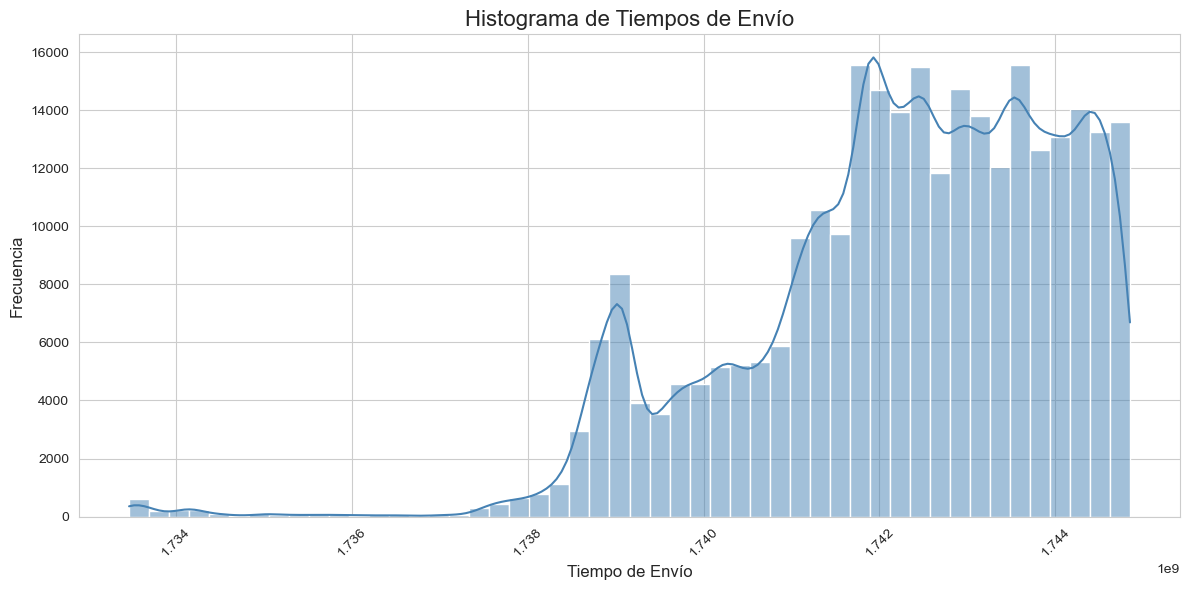

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Lo básico
plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')

# Creo el histograma
ax = sns.histplot(
    data=df_todos_los_envios,
    x='creation_time',  
    bins=50,  # Ajusta el número de bins
    kde=True,  # curva de densidad
    color='steelblue'
)

# Personalizo
plt.title('Histograma de Tiempos de Envío', fontsize=16)
plt.xlabel('Tiempo de Envío', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

# Roto las etiquetas del eje x si las fechas son muy largas
plt.xticks(rotation=45)

# Ajustar el diseño
plt.tight_layout()

# Guardar el gráfico (opcional)
plt.savefig('histograma_tiempos_envio.png', dpi=300)

# Mostrar el gráfico
plt.show()

In [ ]:
#Este histograma sugiere la presencia de al menos dos estrategias o velocidades de envío distintas, probablemente influenciadas por factores económicos como el costo y por factores conductuales como la urgencia del consumidor y la disposición a esperar. Analizar las causas subyacentes de estos dos picos podría llevar a mejoras en la eficiencia del sistema y a una mejor comprensión de las necesidades de los usuarios.

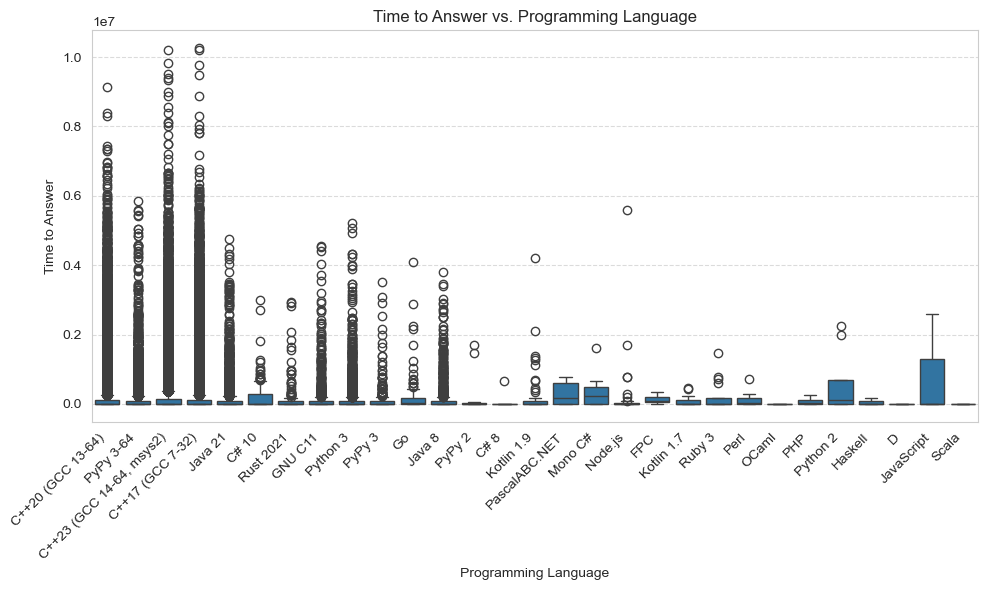

In [146]:
#con el dataframe final
plt.figure(figsize=(10, 6))  
sns.boxplot(x='language', y='time_to_answer', data=df_ok_sorted)

# Uso plot
plt.title('Time to Answer vs. Programming Language')
plt.xlabel('Programming Language')
plt.ylabel('Time to Answer')  
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()  

# Muestro
plt.show()

In [ ]:
#En conclusión, los diagramas de caja sugieren que existen diferencias notables en la distribución del "Time to Answer" entre varios Programming Language. Las variantes de C++ generalmente parecen tener tiempos de respuesta más rápidos,
#mientras que Java 21 parece tener una tendencia a tiempos de respuesta más largos. Sin embargo, es importante considerar las unidades del "Time to Answer", la definición de "Respuesta" y otros posibles factores influyentes para una 
#comprensión más completa.

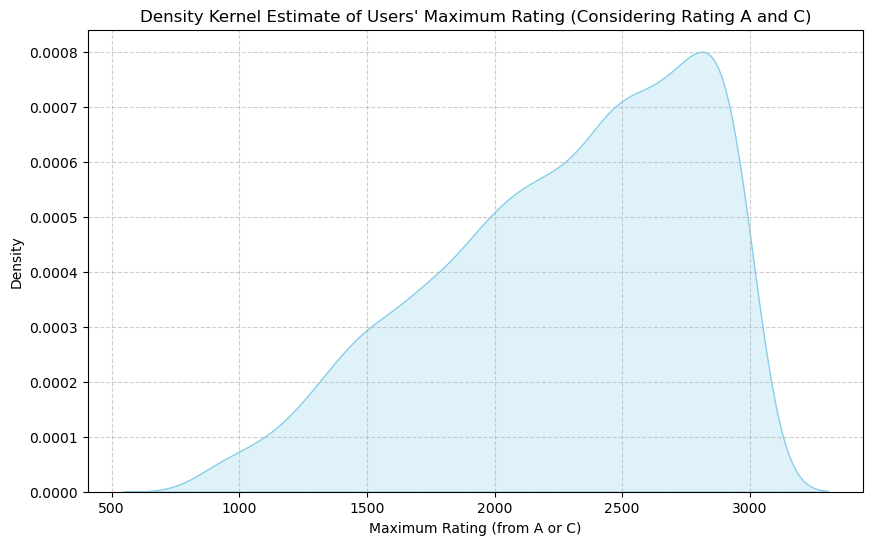

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Encuentra el máximo rating entre rating_A y rating_C para cada fila
df_final['overall_max_rating'] = df_final[['rating_A', 'rating_C']].max(axis=1)

# Encuentra el máximo de ese valor máximo por usuario
max_overall_ratings_per_user = df_final.groupby('user_handle')['overall_max_rating'].max()

# Crea el gráfico de densidad kernel
plt.figure(figsize=(10, 6))
sns.kdeplot(max_overall_ratings_per_user, fill=True, color='skyblue')
plt.title('Density Kernel Estimate of Users\' Maximum Rating (Considering Rating A and C)')
plt.xlabel('Maximum Rating (from A or C)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Si ya no necesitas la columna temporal
df_final.drop('overall_max_rating', axis=1, inplace=True)

In [ ]:
#Este gráfico de densidad muestra cómo se distribuyen los ratings máximos que alcanzan los usuarios, considerando tanto su Rating A como su Rating C. La mayoría de los usuarios tienden a alcanzar sus máximos ratings entre 2500 y 3000, con un pico notable alrededor de 2800. Hay menos usuarios que alcanzan ratings máximos muy bajos (por debajo de 1000) o extremadamente altos (por encima de 3000). La forma de la curva sugiere que el rendimiento máximo de los usuarios tiende a concentrarse en un rango relativamente alto, con una disminución gradual hacia valores más bajos.

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_final is your DataFrame

# Determine the number of bins (you might need to experiment with this)
n_bins = 10  # Example number of bins

# Create bins for 'time_to_answer'
df_final['time_to_answer_bins'] = pd.cut(df_final['time_to_answer'], bins=n_bins, labels=False)

# Calculate the average rating and the midpoint of time_to_answer for each bin
bin_means = df_final.groupby('time_to_answer_bins').agg(
    avg_rating=('rating', 'mean'),
    avg_time=('time_to_answer', 'mean')
).reset_index()

# Create the binscatter plot
plt.figure(figsize=(10, 6))
plt.scatter(bin_means['avg_time'], bin_means['avg_rating'], color='coral', alpha=0.8)
plt.title(f'Binscatter of Rating vs. Time to Answer (using {n_bins} bins)')
plt.xlabel('Average Time to Answer')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Optionally, you can fit a linear regression line to the binned data
sns.lmplot(x='avg_time', y='avg_rating', data=bin_means, scatter=True, ci=None, line_kws={'color': 'black'})
plt.title(f'Binscatter with Linear Fit: Rating vs. Time to Answer (using {n_bins} bins)')
plt.xlabel('Average Time to Answer')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Remember to drop the temporary bin column if you don't need it later
df_final.drop('time_to_answer_bins', axis=1, inplace=True)

KeyError: 'time_to_answer'

In [45]:
# Assuming df_final is your DataFrame

# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='rating_achieved', y='rating', data=df_final, alpha=0.6)

# Fit a linear regression line using seaborn's regplot
sns.regplot(x='rating_achieved', y='rating', data=df_final, scatter=False, color='red')

plt.title('Linear Regression: Rating vs. Rating Achieved')
plt.xlabel('Rating Achieved')
plt.ylabel('Rating')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Alternatively, you can fit the regression manually and plot the line
import numpy as np
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(df_final['rating_achieved'], df_final['rating'])
line = slope * df_final['rating_achieved'] + intercept

plt.figure(figsize=(10, 6))
plt.scatter(df_final['rating_achieved'], df_final['rating'], alpha=0.6)
plt.plot(df_final['rating_achieved'], line, color='red')
plt.title(f'Linear Regression: Rating vs. Rating Achieved (R-squared = {r_value**2:.2f})')
plt.xlabel('Rating Achieved')
plt.ylabel('Rating')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"R-squared: {r_value**2:.2f}")
print(f"P-value: {p_value:.3f}")
print(f"Standard Error of the Slope: {std_err:.2f}")

ValueError: Could not interpret value `rating` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>